
# HUMANITARIANAID ALLOCATION

## SOURCE

https://www.kaggle.com/datasets/amjadaj/humanitarian-aid-100k


## LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## ABOUT DATASET

In [2]:
df=pd.read_csv("humanitarian_aid_dirty_100k.csv")
df.head()

,event_id,country,region,disaster_type,severity,population_affected,infrastructure_damage,accessibility,past_aid_score,weather_risk_index,economic_vulnerability,urgency_level,aid_required_tons
0,1.0,Pakistan,South,Cyclone,4.0,238647.0,35.0,Moderate,1.886317,3.539997,4.623507,NaN,247.83
1,2.0,Sri Lanka,North,Flood,3.0,131248.0,41.0,Easy,5.265394,2.345140,1.961192,Low,188.41
2,3.0,Bangladesh,East,Landslide,1.0,290215.0,86.0,Easy,1.993076,2.863221,6.293526,High,356.25
3,4.0,Sri Lanka,West,Landslide,2.0,224897.0,57.0,Difficult,0.690101,1.895712,5.998988,NaN,285.95
4,5.0,Sri Lanka,West,Earthquake,1.0,41023.0,94.0,Difficult,1.874487,4.587736,5.487458,High,250.08


In [3]:
df.shape

(102000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                99969 non-null  float64
 1   country                 99977 non-null  object 
 2   region                  99958 non-null  object 
 3   disaster_type           99969 non-null  object 
 4   severity                99960 non-null  float64
 5   population_affected     99958 non-null  float64
 6   infrastructure_damage   99956 non-null  float64
 7   accessibility           99969 non-null  object 
 8   past_aid_score          99954 non-null  float64
 9   weather_risk_index      99962 non-null  float64
 10  economic_vulnerability  99960 non-null  float64
 11  urgency_level           99960 non-null  object 
 12  aid_required_tons       99966 non-null  float64
dtypes: float64(8), object(5)
memory usage: 10.1+ MB


In [5]:
df.isnull().sum().sum()

26482

In [6]:
df.duplicated().sum()

2000

In [7]:
#  0   event_id                
#  1   country              
#  2   region                
#  3   disaster_type           
#  4   severity              
#  5   population_affected    
#  6   infrastructure_damage 
#  7   accessibility        
#  8   past_aid_score          
#  9   weather_risk_index     
#  10  economic_vulnerability  
#  11  urgency_level          
#  12  aid_required_tons 

## VISUALIZATION

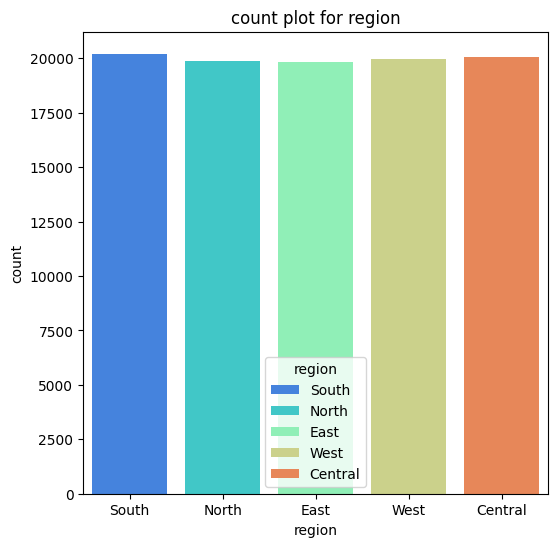

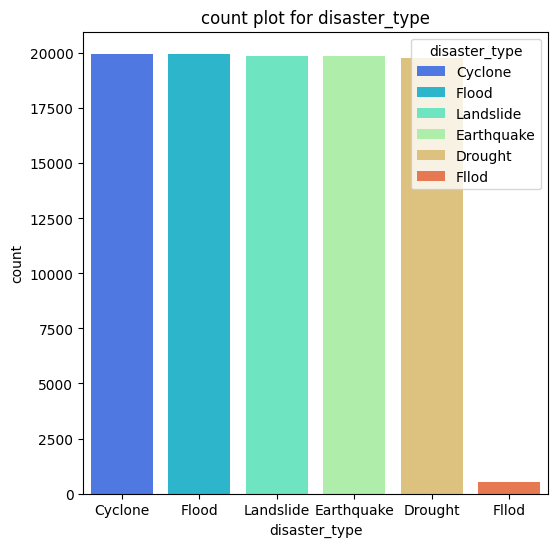

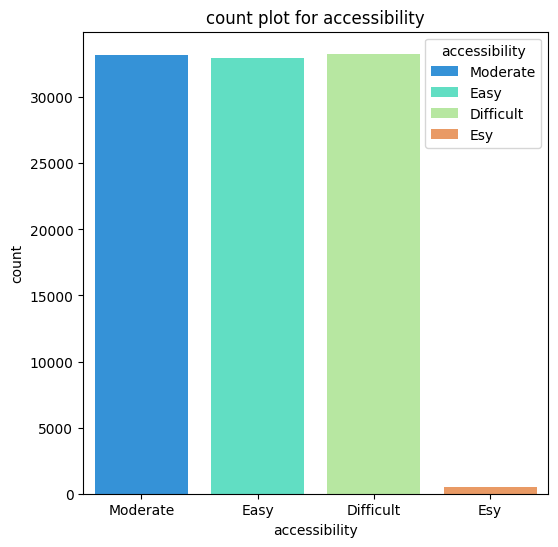

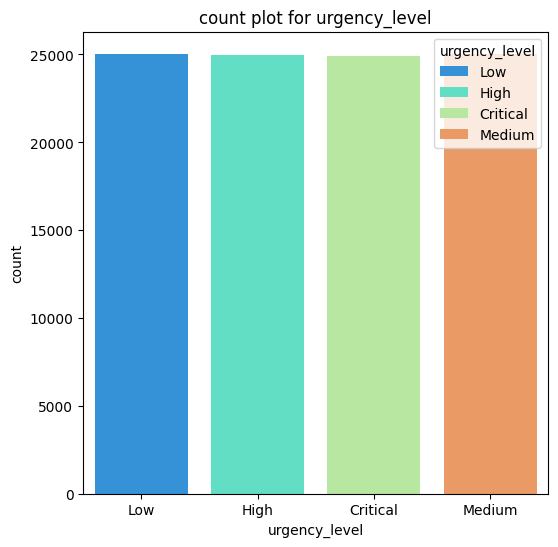

In [8]:
categorical_columns=df.select_dtypes(include=['object','category']).columns.tolist()
for col in categorical_columns[1:]: # skip the fir̥st feature
    plt.figure(figsize=(6,6))
    sns.countplot(data=df,x=col,hue=col,palette='rainbow')
    plt.title(f"count plot for {col}")
    plt.show()

# EDA 

## REMOVING NULL VALUES

In [9]:
df.isnull().sum()

event_id                  2031
country                   2023
region                    2042
disaster_type             2031
severity                  2040
population_affected       2042
infrastructure_damage     2044
accessibility             2031
past_aid_score            2046
weather_risk_index        2038
economic_vulnerability    2040
urgency_level             2040
aid_required_tons         2034
dtype: int64

In [10]:
numerical_cols = ['event_id', 'severity', 'population_affected', 'infrastructure_damage', 'past_aid_score', 'weather_risk_index', 'economic_vulnerability', 'aid_required_tons']
medians = df[numerical_cols].median()

# Calculate modes for categorical columns
categorical_cols = ['country', 'region', 'disaster_type', 'accessibility', 'urgency_level']
modes = df[categorical_cols].mode().iloc[0] 

# Impute null values
df[numerical_cols] = df[numerical_cols].fillna(medians)
df[categorical_cols] = df[categorical_cols].fillna(modes)

# Convert 'event_id' to integer, as it represents an ID
# We need to ensure there are no non-numeric or NaN values left (which fillna should have handled)
df['event_id'] = df['event_id'].astype(int)

print(df.isnull().sum())


event_id                  0
country                   0
region                    0
disaster_type             0
severity                  0
population_affected       0
infrastructure_damage     0
accessibility             0
past_aid_score            0
weather_risk_index        0
economic_vulnerability    0
urgency_level             0
aid_required_tons         0
dtype: int64


## REMOVING DUPLICATES

In [11]:
df.duplicated().sum()

2000

In [12]:
df=df.drop_duplicates()

In [13]:
df.shape

(100000, 13)

## REMOVING UNWANTED COLUMNS

In [14]:
df= df.drop(columns=['event_id','country','region','past_aid_score','weather_risk_index'],axis=1)
#It has no relationship with disaster severity or aid needed.

## ENCODING

In [15]:
df.info()
# in there have 5 object coloumn and encoding the values 

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   disaster_type           100000 non-null  object 
 1   severity                100000 non-null  float64
 2   population_affected     100000 non-null  float64
 3   infrastructure_damage   100000 non-null  float64
 4   accessibility           100000 non-null  object 
 5   economic_vulnerability  100000 non-null  float64
 6   urgency_level           100000 non-null  object 
 7   aid_required_tons       100000 non-null  float64
dtypes: float64(5), object(3)
memory usage: 6.9+ MB


In [16]:
df['urgency_level'].value_counts()

urgency_level
Medium      26557
Low         24511
Critical    24482
High        24450
Name: count, dtype: int64

In [17]:
df['accessibility'].value_counts()

accessibility
Difficult    34639
Moderate     32538
Easy         32323
Esy            500
Name: count, dtype: int64

In [18]:
df['accessibility'] = df['accessibility'].replace("Esy", "Normal")

In [19]:
df['accessibility'] = df['accessibility'].replace("Easy", "Easy")

In [20]:
df=df.replace({'Fllod':'volcano_erruption'})

In [21]:
df['disaster_type'].value_counts()

disaster_type
Cyclone              21590
Flood                19582
Landslide            19467
Earthquake           19458
Drought              19403
volcano_erruption      500
Name: count, dtype: int64

In [22]:
df['severity'].value_counts()

severity
3.0    21751
5.0    19842
4.0    19504
2.0    19468
1.0    19435
Name: count, dtype: int64

In [23]:
le=LabelEncoder()

In [24]:
obj_col=df.select_dtypes(include=['object'])
obj_col=df.drop(columns=['accessibility','urgency_level',])
for col in obj_col:
    df[col]=le.fit_transform(df[col])

In [25]:
le

LabelEncoder()

### OTHER OBJECT COLUMN MAPING


In [26]:
df['disaster_type'].value_counts()

disaster_type
0    21590
3    19582
4    19467
2    19458
1    19403
5      500
Name: count, dtype: int64

In [27]:
df['urgency_level'].value_counts()

urgency_level
Medium      26557
Low         24511
Critical    24482
High        24450
Name: count, dtype: int64

In [28]:
df['accessibility'].value_counts()

accessibility
Difficult    34639
Moderate     32538
Easy         32323
Normal         500
Name: count, dtype: int64

## MAPING

In [29]:
df['urgency_level']=df['urgency_level'].map({'Medium':1,
                                             'Low':0,
                                             'Critical':3,
                                             'High':2
                                             })

df['accessibility']=df['accessibility'].map({'Difficult':3,
                                             'Moderate':2,
                                             'Easy':0,
                                             'Normal':1
                                             })

In [30]:
df['accessibility'].unique()

array([2, 0, 3, 1], dtype=int64)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   disaster_type           100000 non-null  int32
 1   severity                100000 non-null  int64
 2   population_affected     100000 non-null  int64
 3   infrastructure_damage   100000 non-null  int64
 4   accessibility           100000 non-null  int64
 5   economic_vulnerability  100000 non-null  int64
 6   urgency_level           100000 non-null  int64
 7   aid_required_tons       100000 non-null  int64
dtypes: int32(1), int64(7)
memory usage: 6.5 MB


# OUTLIERS


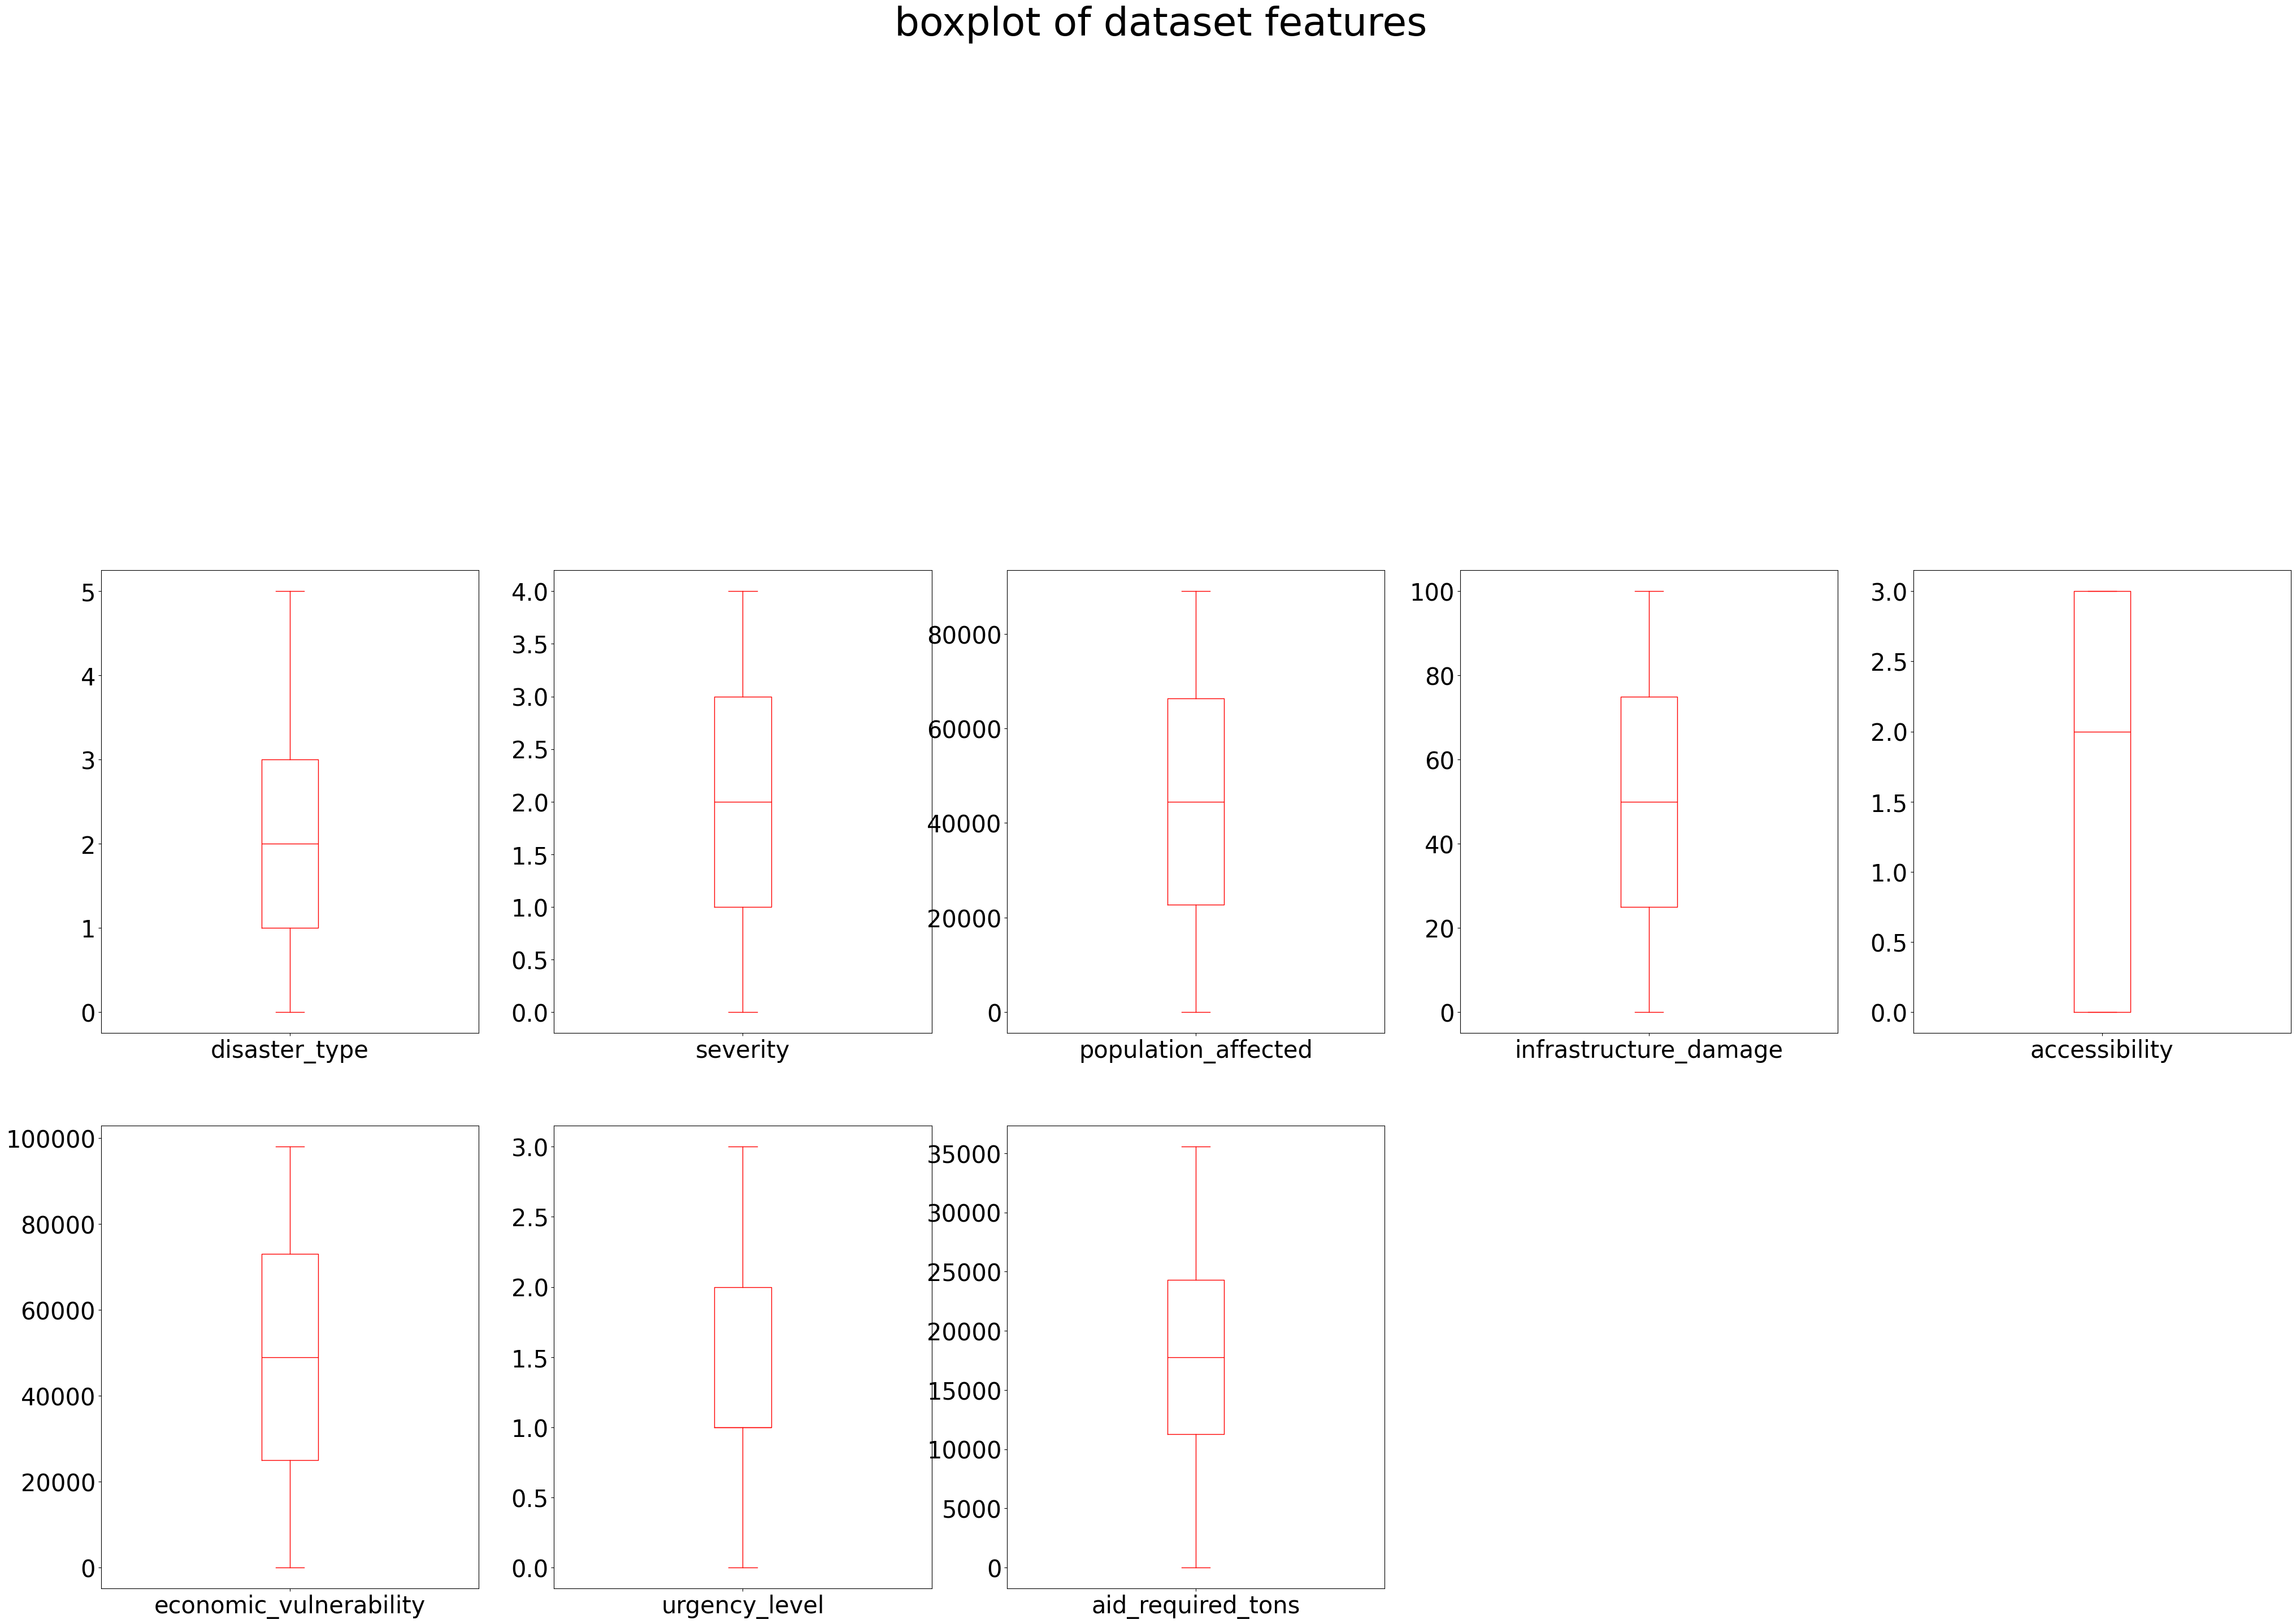

In [32]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(50,100),color='red',fontsize=30)
plt.suptitle('boxplot of dataset features',fontsize=50)
plt.show()

In [33]:
# THERE IS NO OUTLIES 
# if it have outliers we use IQR method
## create  a copy of the  original data for comparison
# df_copy=df.copy()

# def remove_outliers_iqr(df,exclude_columns):
#     # loop through numeric columns
#     for column in df.select_dtypes(include=[int,float]):
#         if column in exclude_columns:
#             continue # skip excluded columns

#         Q1=df[column].quantile(0.25)
#         Q3=df[column].quantile(0.75)
#         IQR=Q3-Q1

#         #define outlier bound
#         lower_bound= Q1-1.5 * IQR
#         upper_bound= Q3+1.5 * IQR

#         # filter out the outliers
#         df=df[(df[column]>=lower_bound)&(df[column]<=upper_bound)]

#     return df



# SKEWNESS

In [34]:
df.skew() # there is no skewness becuse the values are below 1

disaster_type             0.042403
severity                 -0.006221
population_affected       0.000874
infrastructure_damage     0.009324
accessibility            -0.412182
economic_vulnerability   -0.000045
urgency_level             0.027029
aid_required_tons         0.001426
dtype: float64

In [35]:
# if we have any skew value we use (log,sqrl,etc) 
# for col in df.select_dtypes(include='number'):
#     if skew(df[col]) > 1:
#         df[col] = np.log1p(df[col])

# CHEKING CORRELATION

In [36]:
corr=df.corr()
corr

,disaster_type,severity,population_affected,infrastructure_damage,accessibility,economic_vulnerability,urgency_level,aid_required_tons
disaster_type,1.000000,-0.004213,-0.002876,-0.003596,0.002635,-0.000525,0.000409,-0.005167
severity,-0.004213,1.000000,0.000987,-0.006664,-0.000033,-0.001381,-0.000236,0.139452
population_affected,-0.002876,0.000987,1.000000,0.004594,0.000472,0.001613,0.001149,0.752374
infrastructure_damage,-0.003596,-0.006664,0.004594,1.000000,0.002971,-0.000635,0.001240,0.601880
accessibility,0.002635,-0.000033,0.000472,0.002971,1.000000,0.000750,-0.005822,0.000883
economic_vulnerability,-0.000525,-0.001381,0.001613,-0.000635,0.000750,1.000000,0.003301,0.102681
urgency_level,0.000409,-0.000236,0.001149,0.001240,-0.005822,0.003301,1.000000,0.001070
aid_required_tons,-0.005167,0.139452,0.752374,0.601880,0.000883,0.102681,0.001070,1.000000


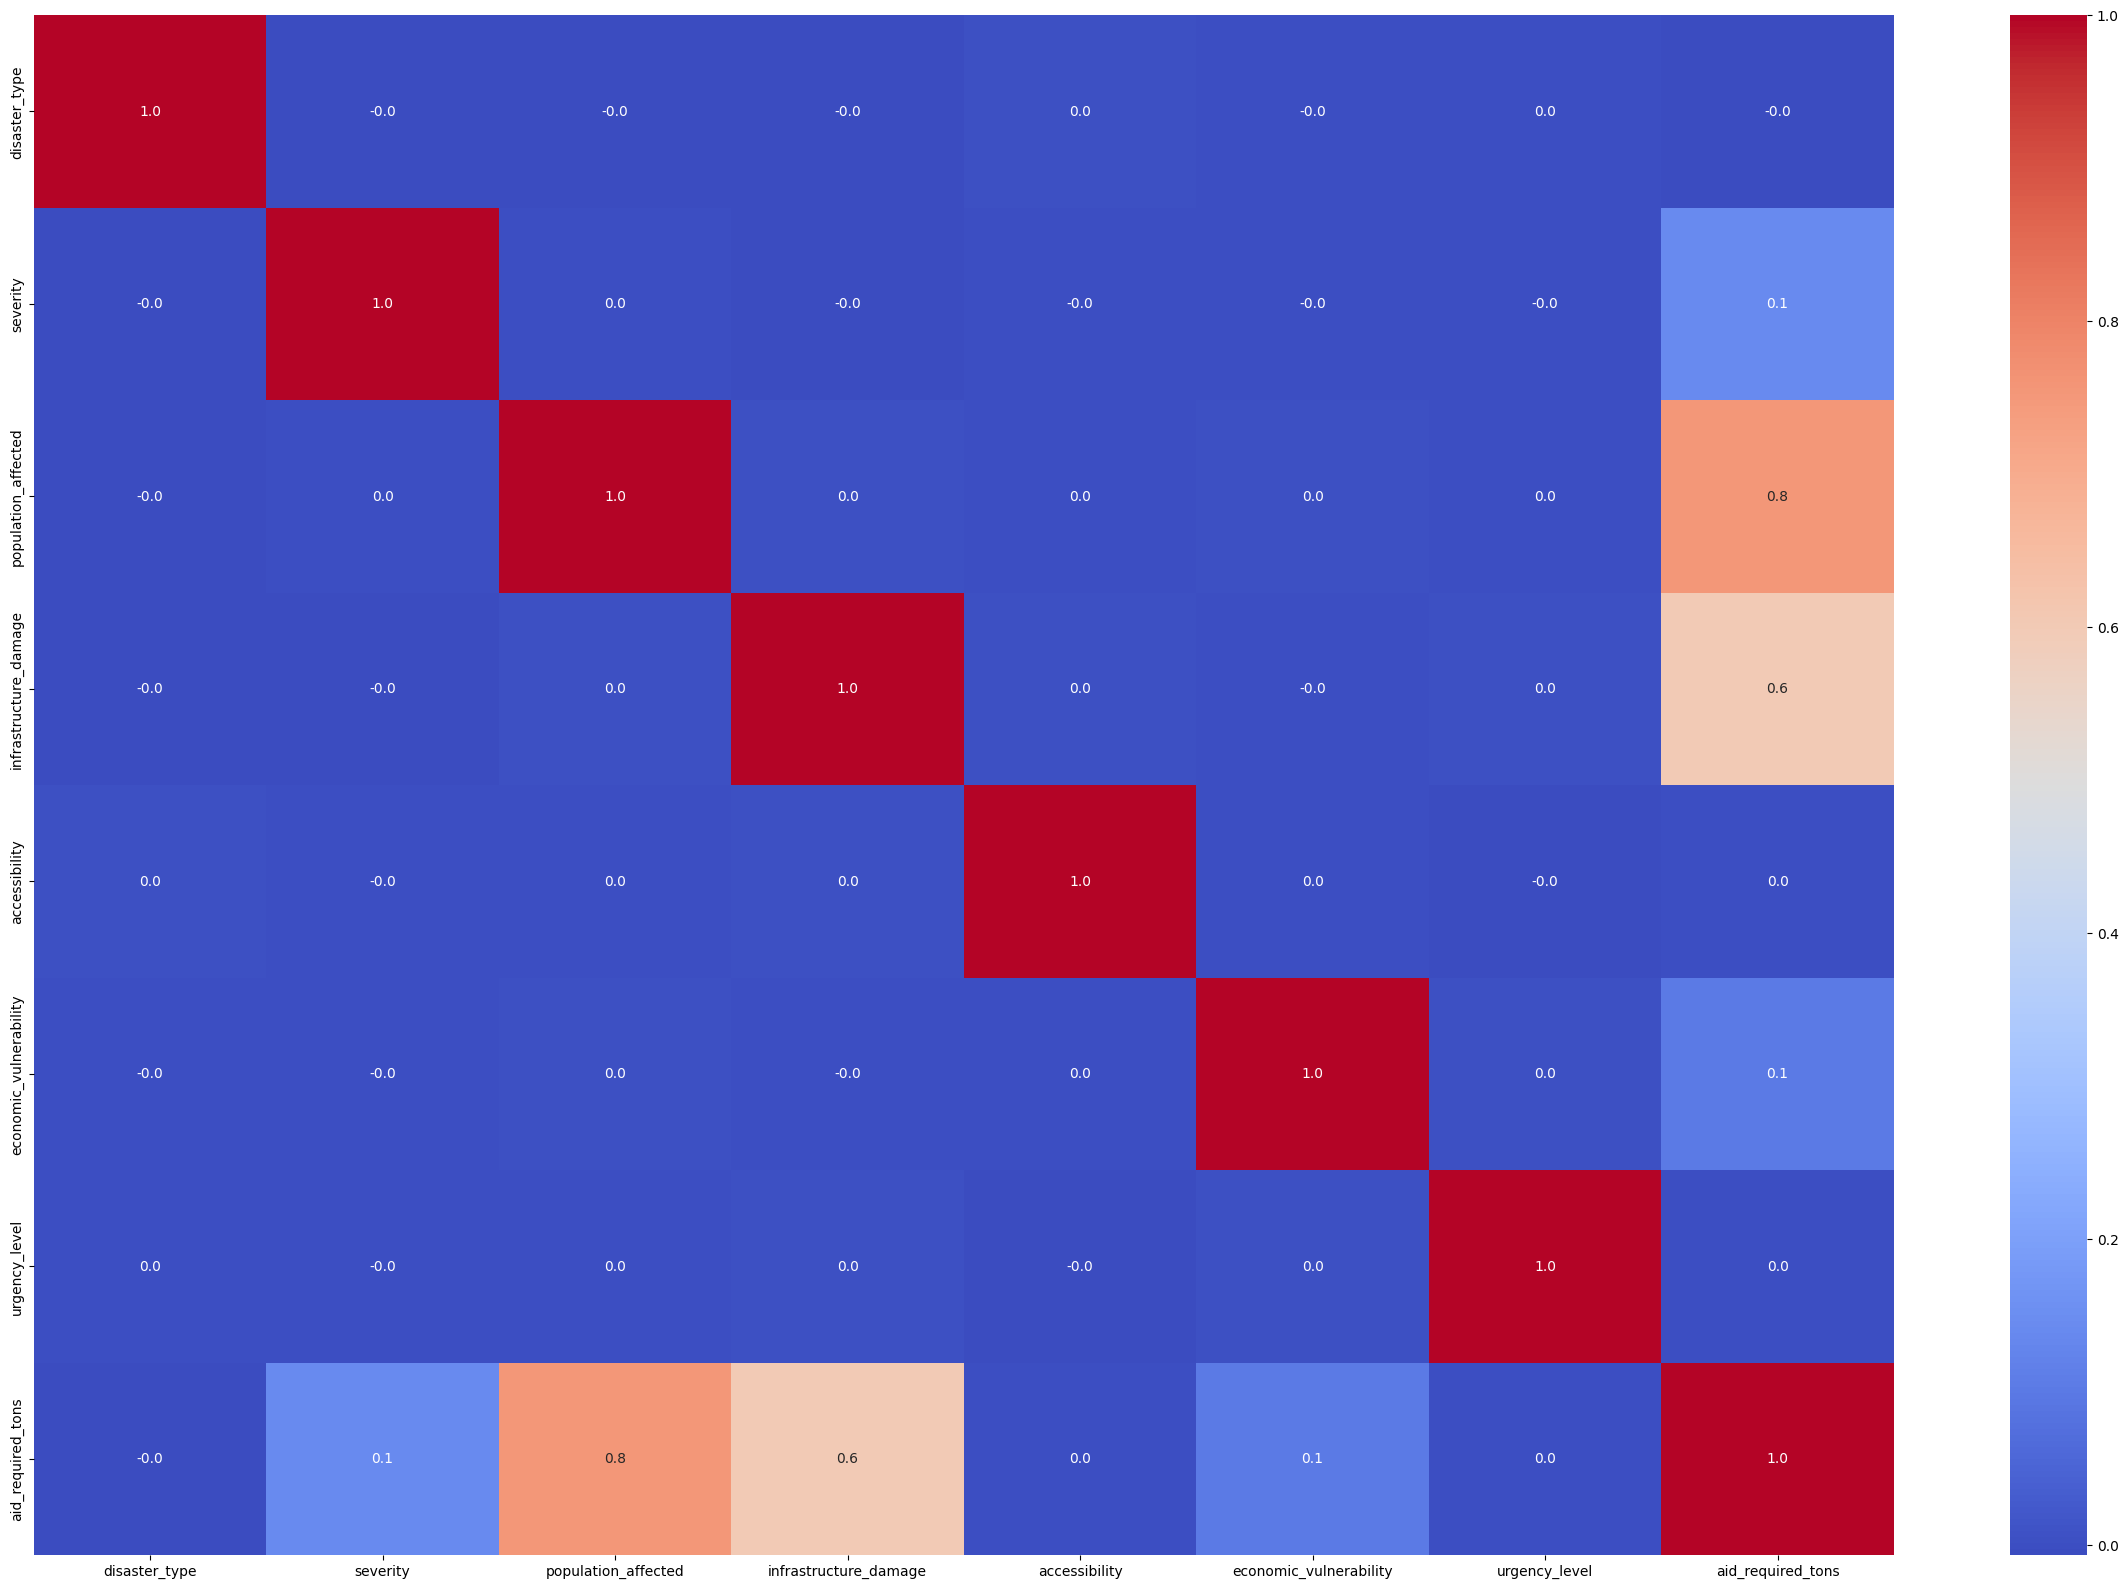

In [37]:
plt.figure(figsize=(30,20))
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='0.01f')
plt.show()

In [38]:
# there is not large correlation 

# MODEL SPLITING, TRAIN AND TEST

In [39]:
x=df.drop(columns=['aid_required_tons'])
y=df['aid_required_tons']

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
print('shape of training featurs:',x_train.shape)
print('shape of testing featurs:',x_test.shape)
print('shape of training featurs:',y_train.shape)
print('shape of testing featurs:',y_test.shape)

shape of training featurs: (80000, 7)
shape of testing featurs: (20000, 7)
shape of training featurs: (80000,)
shape of testing featurs: (20000,)


## SCALING

In [42]:
std=StandardScaler()
x=std.fit_transform(x)
df

,disaster_type,severity,population_affected,infrastructure_damage,accessibility,economic_vulnerability,urgency_level,aid_required_tons
0,0,3,42284,35,2,64799,1,15330
1,3,2,23129,41,0,27494,0,9642
2,4,0,51506,86,0,88109,2,25856
3,4,1,39836,57,3,84010,1,19058
4,2,0,7177,94,3,76883,2,15550
...,...,...,...,...,...,...,...,...
99995,0,3,86936,99,0,59536,1,35472
99996,1,4,74289,57,2,20175,3,27606
99997,0,2,27842,50,3,23020,3,19399
99998,0,4,77789,40,2,10328,1,25410


In [43]:
std

StandardScaler()

# CHECKING WHICH ALGORITHMN IS  BEST 

In [44]:
# for regression algorithmn
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

In [45]:
clas_model={
            'rfc':RandomForestRegressor(criterion='squared_error',max_depth=20,min_samples_split=2),
            'dtc':DecisionTreeRegressor(
    criterion='squared_error', 
    splitter='best',  
    max_depth=5,           
    min_samples_split=2,           
    min_samples_leaf=1,     
    max_features=None,          
    random_state=42
),
           
            'svm':SVR(kernel='linear',C=1.0,  epsilon=0.1,max_iter=5000),
            'gbc':GradientBoostingRegressor(
     n_estimators=200,
    learning_rate=0.05,
    max_depth=4,      
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,       
    random_state=42),
            'lireg':LinearRegression(),
            'xgbr':XGBRegressor(
     n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42),
            }

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# dictionary to stoore risult
result=  {  'Model': [],
    'Mean Absolute Error (MAE)': [],
    'Mean Squared Error (MSE)': [],
    'Root Mean Squared Error (RMSE)': [],
    'R2 Score': []
    }

# evaluate each model 
for model_name, model in clas_model.items():
    # train the model 
    model.fit(x_train,y_train)
    model_pred=model.predict(x_test)
    
    # calculate metrics 
    mae=mean_absolute_error(y_test,model_pred)
    mse=mean_squared_error(y_test,model_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,model_pred)
    

    print("------------------------------------------------------------")
    print(model_name)
    print(model.get_params())
    print("------------------------------------------------------------")
    result['Model'].append(model_name)
    result["Mean Absolute Error (MAE)"].append(mae)
    result['Mean Squared Error (MSE)'].append(mse)
    result['Root Mean Squared Error (RMSE)'].append(rmse)
    result['R2 Score'].append(r2)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE:{mse:,.2f} ")
print(f"Root Mean Squared Error (RMSE):{rmse:,.2f}")
print(f"R2 Score  {r2:.2f}")

------------------------------------------------------------
rfc
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
------------------------------------------------------------
------------------------------------------------------------
dtc
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
------------------------------------------------------------


C:\Users\Pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


------------------------------------------------------------
svm
{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': 5000, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------------------------------
------------------------------------------------------------
gbc
{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.8, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
------------------------------------------------------------
------------------------------------------------------------
lireg
{'copy_X': True, 'fit_intercept': True, 'n

In [47]:
# convert result to a dataframe
result_df=pd.DataFrame(result)

# display the result in a table
result_df

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R2 Score
0,rfc,888.701924,3.592034e+06,1895.266219,0.951734
1,dtc,2096.382664,7.981261e+06,2825.112591,0.892757
2,svm,96601.304361,1.323365e+10,115037.613053,-176.819272
3,gbc,790.030210,3.260140e+06,1805.585864,0.956194
4,lireg,865.906690,3.388009e+06,1840.654380,0.954476
5,xgbr,802.591980,3.345584e+06,1829.093901,0.955046


# GRADIENT BOOSTING REGRESSOR

In [48]:
modell=GradientBoostingRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=4,      
min_samples_split=2,
min_samples_leaf=1,
subsample=0.8,       
random_state=42,)

modell.fit(x_train, y_train)


y_pred = modell.predict(x_test)

#  Evaluation
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)



print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE:{mse:,.2f} ")
print(f"Root Mean Squared Error (RMSE):{rmse:,.2f}")
print(f"R2 Score  {r2:.2f}")


Mean Absolute Error (MAE): 790.03
Mean Squared Error (MSE:3,260,140.31 
Root Mean Squared Error (RMSE):1,805.59
R2 Score  0.96


In [49]:
modell.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.05,
 'loss': 'squared_error',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 200,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 0.8,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

# SAVING WITH PICKLE FILE

### LABEL ENCODER SAVING

In [50]:
import pickle
with open("LABEL_ENCODER.pkl", "wb") as file:
    pickle.dump(le, file)

print("Model saved successfully!")


Model saved successfully!


In [51]:
# import pickle
# with open("features.pkl", "wb") as file:
#     pickle.dump(x, file)

# print("Model saved successfully!")

### SCALING SVAING

In [52]:
import pickle
with open("SCALE_MODEL.pkl", "wb") as file:
    pickle.dump(std, file)

print("Model saved successfully!")

Model saved successfully!


### MODEL SAVING

In [53]:
import pickle
with open("AID_ALLOCATION.pkl", "wb") as file:
    pickle.dump(modell, file)

print("Model saved successfully!")


Model saved successfully!
